# Ours vs Ragnarok Baseline – Head-to-Head

Compact comparison against the Ragnarok-style baseline (BM25 -> RankZephyr listwise),
stripped of pipeline-internal diagnostics.

**Goldset:** `7a_dicty_gold_llm_public` (n=1,656 queries, full public split).

**Scope:**
1. First-stage retrieval — ours BM25+Dense fusion vs Ragnarok BM25 (Recall@K)
2. Reranking — ours CrossEncoder + PostRerankFusion vs Ragnarok+ZephyrReranker (MRR@K)

**Caveats:** Ragnarok BM25 is Pyserini/Anserini-tuned, ours is PyTerrier; the BM25
stage is therefore not a fully matched comparison. The intended comparison is at
the *design* level (single BM25 vs hybrid retrieval; CE vs listwise LLM rerank),
not parameter-matched re-implementations. Ragnarok runs are capped at top-100.

## 1. Imports and Setup

In [12]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

## 2. Paths and Data Loading

In [13]:
base_dir = Path.cwd().resolve()
if not (base_dir / "output").exists() and (base_dir.parent / "output").exists():
    base_dir = base_dir.parent
print("Base dir:", base_dir)

wdir = base_dir / "output" / "workflow_vega_7a_public_goldset_both_routes"
baseline_dir = base_dir / "output" / "ragnarok_baseline"
goldset_jsonl = base_dir / "output" / "dicty_gold_build" / "7a_dicty_gold_llm_public.jsonl"
output_dir = baseline_dir / "figures"
output_dir.mkdir(parents=True, exist_ok=True)

SPLIT = "7a_dicty_gold_llm_public"

Base dir: /Users/yun/develop/dictycite


In [14]:
# Single shared color palette, single shared label set.
COLORS = {
    "ours_fusion":     "#2ca02c",
    "ours_ce":         "#d62728",
    "ours_postfusion": "#9467bd",
    "rag_bm25":        "#1f77b4",
    "rag_rerank":      "#17becf",
}
LABELS = {
    "ours_fusion":     "Ours: BM25+Dense Fusion",
    "ours_ce":         "Ours: CrossEncoder",
    "ours_postfusion": "Ours: Post-rerank Fusion",
    "rag_bm25":        "Ragnarok: BM25",
    "rag_rerank":      "Ragnarok: BM25 + RankZephyr",
}

## 3. Load Qrels and Run Files

In [15]:
def _extract_pmid(doc_entry):
    if isinstance(doc_entry, dict):
        doc_entry = doc_entry.get("document", "")
    if not isinstance(doc_entry, str):
        return None
    return doc_entry.rsplit("/", 1)[-1] if "/" in doc_entry else doc_entry


def load_qrels(path: Path) -> dict[str, set[str]]:
    qrels: dict[str, set[str]] = {}
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            q = json.loads(line)
            qid = str(q.get("query_id", q.get("id", "")))
            pmids = {_extract_pmid(d) for d in q.get("documents", []) if _extract_pmid(d)}
            if qid and pmids:
                qrels[qid] = pmids
    return qrels


qrels = load_qrels(goldset_jsonl)
print(f"Loaded qrels: {len(qrels)} queries")

Loaded qrels: 1656 queries


In [16]:
def load_run_tsv(path: Path) -> dict[str, list[str]]:
    df = pd.read_csv(path, sep="\t")
    cols = {c.lower(): c for c in df.columns}
    qid_col = cols["qid"]
    doc_col = cols.get("docno") or cols.get("docid") or cols.get("doc")
    rank_col = cols.get("rank")
    df[qid_col] = df[qid_col].astype(str)
    df[doc_col] = df[doc_col].astype(str)
    if rank_col:
        df = df.sort_values([qid_col, rank_col])
    return {str(qid): g[doc_col].tolist() for qid, g in df.groupby(qid_col, sort=False)}


def load_run_trec(path: Path) -> dict[str, list[str]]:
    """TREC 6-col format: qid Q0 docid rank score tag (whitespace separated)."""
    df = pd.read_csv(
        path, sep=r"\s+", header=None,
        names=["qid", "Q0", "docid", "rank", "score", "tag"],
        engine="python",
    )
    df["qid"] = df["qid"].astype(str)
    df["docid"] = df["docid"].astype(str)
    df = df.sort_values(["qid", "rank"])
    return {str(qid): g["docid"].tolist() for qid, g in df.groupby("qid", sort=False)}


runs: dict[str, dict[str, list[str]]] = {
    "ours_fusion":     load_run_tsv(wdir / "retrieval" / "fusion" / "runs" / "best_rrf_7a_dicty_gold_llm_public_top5000.tsv"),
    "ours_ce":         load_run_tsv(wdir / "rerank" / "cross_encoder" / "runs" / "best_rrf_7a_dicty_gold_llm_public_top5000.tsv"),
    "ours_postfusion": load_run_tsv(wdir / "rerank" / "post_rerank_fusion" / "runs" / "best_rrf_7a_dicty_gold_llm_public_top5000_rrf_poolR50_poolH50_k60.tsv"),
    "rag_bm25":        load_run_trec(baseline_dir / "runs" / "bm25_run.txt"),
    "rag_rerank":      load_run_trec(baseline_dir / "runs" / "rerank_run.txt"),
}
for name, run in runs.items():
    print(f"{name:18s}: {len(run)} qids")

ours_fusion       : 1656 qids
ours_ce           : 1656 qids
ours_postfusion   : 1656 qids
rag_bm25          : 1656 qids
rag_rerank        : 1656 qids


## 4. Metric Helpers

In [17]:
def recall_at_k(docs: list[str], rels: set[str], k: int) -> float:
    if not rels:
        return 0.0
    return sum(1 for d in docs[:k] if d in rels) / len(rels)


def mrr_at_k(docs: list[str], rels: set[str], k: int) -> float:
    for i, doc in enumerate(docs[:k], 1):
        if doc in rels:
            return 1.0 / i
    return 0.0


def mean_at_ks(run, qrels_, ks, fn) -> dict[int, float]:
    per_q = {k: [] for k in ks}
    for qid, docs in run.items():
        rels = qrels_.get(qid)
        if not rels:
            continue
        for k in ks:
            per_q[k].append(fn(docs, rels, k))
    return {k: float(np.mean(v)) if v else 0.0 for k, v in per_q.items()}

## 5. Headline Summary Table

In [18]:
summary_methods = ["ours_fusion", "ours_ce", "ours_postfusion", "rag_bm25", "rag_rerank"]
recall_ks_short = [10, 50, 100]
mrr_ks_short = [1, 5, 10]

rows = []
for m in summary_methods:
    rec = mean_at_ks(runs[m], qrels, recall_ks_short, recall_at_k)
    mr = mean_at_ks(runs[m], qrels, mrr_ks_short, mrr_at_k)
    rows.append({
        "method": LABELS[m],
        **{f"Recall@{k}": rec[k] for k in recall_ks_short},
        **{f"MRR@{k}": mr[k] for k in mrr_ks_short},
    })
summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
summary_df.to_csv(output_dir / "summary_table.csv", index=False)

                     method  Recall@10  Recall@50  Recall@100  MRR@1  MRR@5  MRR@10
    Ours: BM25+Dense Fusion     0.7080     0.8370      0.8704 0.4825 0.5583  0.5678
         Ours: CrossEncoder     0.7321     0.8471      0.8809 0.5199 0.5984  0.6052
   Ours: Post-rerank Fusion     0.7528     0.8471      0.8837 0.5302 0.6132  0.6202
             Ragnarok: BM25     0.7133     0.8205      0.8503 0.5290 0.5970  0.6041
Ragnarok: BM25 + RankZephyr     0.6914     0.8321      0.8503 0.4789 0.5586  0.5660


## 6. Supplement Fig S1 — First-stage Retrieval: Recall@K

*Paper role:* supplement, recall-side justification for the fusion stage.
Referenced from main-paper §3.1 to support "fusion improves the candidate pool
even though it does not improve top-position MRR."

Ours BM25+Dense fusion vs Ragnarok BM25.
Ragnarok BM25 retrieves top-100, so the curve is plotted up to K=100.

Saved: /Users/yun/develop/dictycite/output/ragnarok_baseline/figures/01_retrieval_recall.png


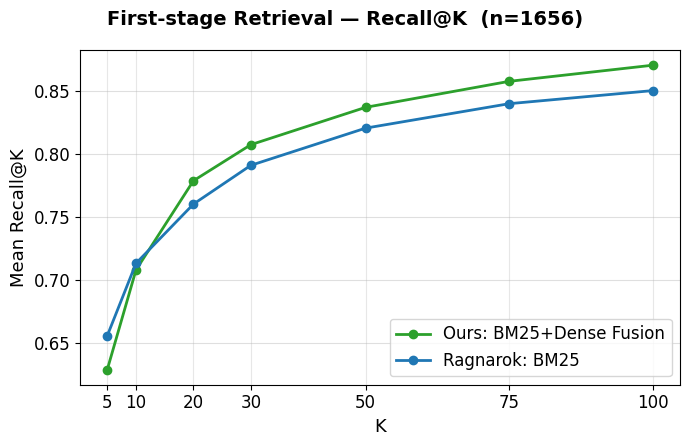

In [19]:
recall_ks = [5, 10, 20, 30, 50, 75, 100]
retrieval_methods = ["ours_fusion", "rag_bm25"]

retrieval_recall = {m: mean_at_ks(runs[m], qrels, recall_ks, recall_at_k) for m in retrieval_methods}

fig, ax = plt.subplots(figsize=(7, 4.5))
for m in retrieval_methods:
    vals = [retrieval_recall[m][k] for k in recall_ks]
    ax.plot(
        recall_ks, vals,
        marker="o", markersize=6, linewidth=2.0,
        color=COLORS[m], label=LABELS[m],
    )

ax.set_xlabel("K")
ax.set_ylabel("Mean Recall@K")
ax.set_xticks(recall_ks)
ax.set_xticklabels([str(k) for k in recall_ks])
ax.grid(True, axis="y", alpha=0.4)
ax.grid(True, axis="x", alpha=0.3)
ax.legend(fontsize=12, loc="lower right")
fig.suptitle(f"First-stage Retrieval — Recall@K  (n={len(qrels)})", fontsize=14, fontweight="bold")
plt.tight_layout()
fig_path = output_dir / "01_retrieval_recall.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 7. Supplement Fig S2 — Full Pipeline vs Ragnarok: Reranking MRR@K

*Paper role:* supplement, full pipeline-vs-baseline comparison including
Post-rerank Fusion (the deployment configuration). Fig 1 in the main paper
uses a focused subset of these methods.

Ours CrossEncoder and Post-rerank Fusion vs Ragnarok+RankZephyr listwise.
The first-stage fusion is shown as a thin gray reference so the rerank delta is visible.

Saved: /Users/yun/develop/dictycite/output/ragnarok_baseline/figures/02_rerank_mrr.png


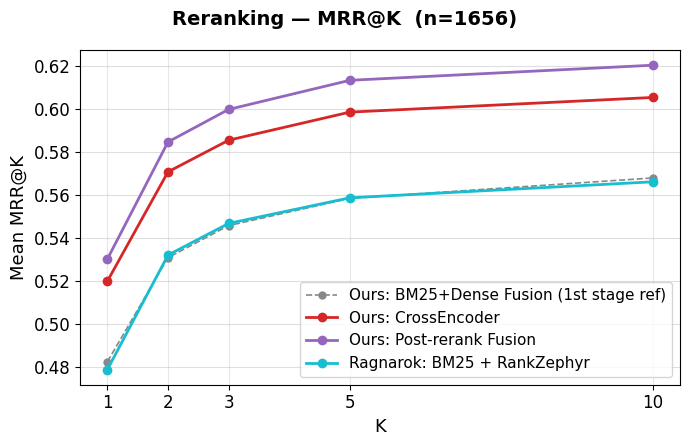

In [20]:
mrr_ks = [1, 2, 3, 5, 10]
rerank_methods = ["ours_fusion", "ours_ce", "ours_postfusion", "rag_rerank"]

rerank_mrr = {m: mean_at_ks(runs[m], qrels, mrr_ks, mrr_at_k) for m in rerank_methods}

fig, ax = plt.subplots(figsize=(7, 4.5))

# Reference: first-stage fusion as a thin gray dashed line
ref_vals = [rerank_mrr["ours_fusion"][k] for k in mrr_ks]
ax.plot(
    mrr_ks, ref_vals,
    marker="o", markersize=5, linewidth=1.2,
    color="#888888", linestyle="--",
    label=LABELS["ours_fusion"] + " (1st stage ref)",
)

for m in ["ours_ce", "ours_postfusion", "rag_rerank"]:
    vals = [rerank_mrr[m][k] for k in mrr_ks]
    ax.plot(
        mrr_ks, vals,
        marker="o", markersize=6, linewidth=2.0,
        color=COLORS[m], label=LABELS[m],
    )

ax.set_xlabel("K")
ax.set_ylabel("Mean MRR@K")
ax.set_xticks(mrr_ks)
ax.set_xticklabels([str(k) for k in mrr_ks])
ax.grid(True, axis="y", alpha=0.4)
ax.grid(True, axis="x", alpha=0.3)
ax.legend(fontsize=11, loc="lower right")
fig.suptitle(f"Reranking — MRR@K  (n={len(qrels)})", fontsize=14, fontweight="bold")
plt.tight_layout()
fig_path = output_dir / "02_rerank_mrr.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 8. Headline Bar — MRR@10 and Recall@100 Side-by-Side

Saved: /Users/yun/develop/dictycite/output/ragnarok_baseline/figures/03_headline_bar.png


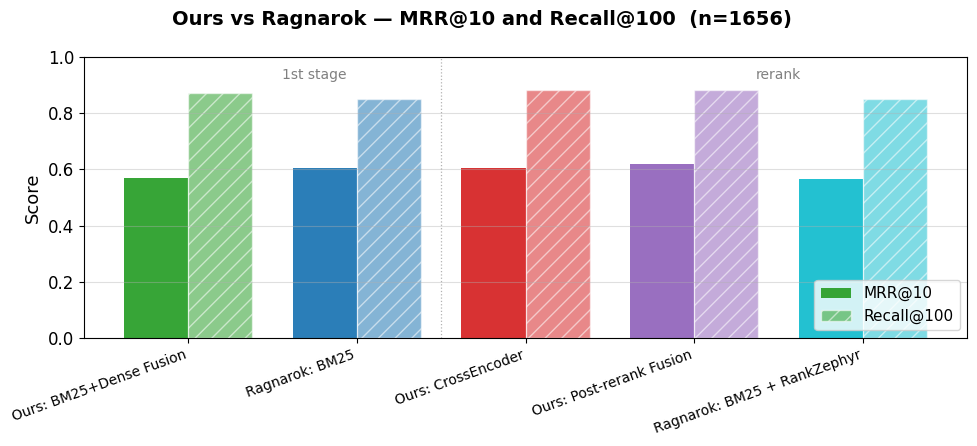

In [21]:
bar_methods = ["ours_fusion", "rag_bm25", "ours_ce", "ours_postfusion", "rag_rerank"]
mrr10 = {m: mean_at_ks(runs[m], qrels, [10], mrr_at_k)[10] for m in bar_methods}
rec100 = {m: mean_at_ks(runs[m], qrels, [100], recall_at_k)[100] for m in bar_methods}

x = np.arange(len(bar_methods))
width = 0.38

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - width / 2, [mrr10[m] for m in bar_methods], width,
       color=[COLORS[m] for m in bar_methods], alpha=0.95, label="MRR@10")
ax.bar(x + width / 2, [rec100[m] for m in bar_methods], width,
       color=[COLORS[m] for m in bar_methods], alpha=0.55, label="Recall@100",
       hatch="//", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels([LABELS[m] for m in bar_methods], rotation=20, ha="right", fontsize=10)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.0)
ax.axvline(x=1.5, color="gray", linestyle=":", linewidth=0.9, alpha=0.6)
ax.text(0.75, 0.96, "1st stage", fontsize=10, color="gray", ha="center", va="top",
        transform=ax.get_xaxis_transform())
ax.text(3.5, 0.96, "rerank", fontsize=10, color="gray", ha="center", va="top",
        transform=ax.get_xaxis_transform())
ax.grid(True, axis="y", alpha=0.4)
ax.legend(fontsize=11, loc="lower right")
fig.suptitle(f"Ours vs Ragnarok — MRR@10 and Recall@100  (n={len(qrels)})",
             fontsize=14, fontweight="bold")
plt.tight_layout()
fig_path = output_dir / "03_headline_bar.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 9. Figure 1 Candidate — "Stage upgrades plateau on dicty"

Single-panel motivation figure for the main paper: MRR@K curves showing the
ladder BM25 -> BM25+Dense Fusion -> CrossEncoder, with Ragnarok+RankZephyr as
an external SOTA reference. The narrow y-range makes the small deltas legible.
Visual hierarchy: BM25 light, Fusion mid, CE bold, Ragnarok dashed reference.

Saved: /Users/yun/develop/dictycite/output/ragnarok_baseline/figures/fig1_candidate_mrr_plateau.png


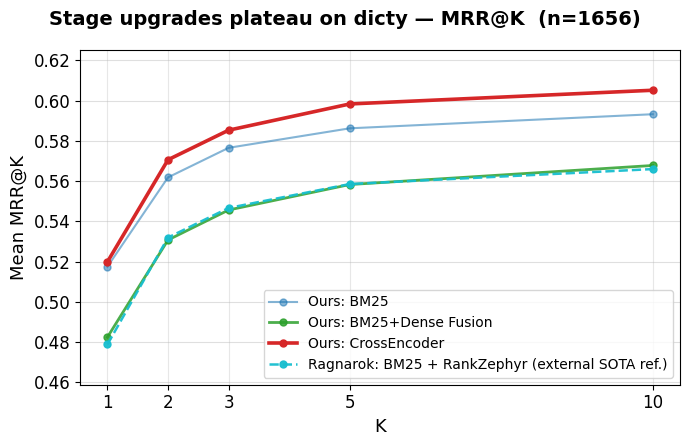


MRR@10 deltas vs BM25:
  ours_bm25          MRR@10=0.5933  delta=+0.0000
  ours_fusion        MRR@10=0.5678  delta=-0.0255
  ours_ce            MRR@10=0.6052  delta=+0.0119
  rag_rerank         MRR@10=0.5660  delta=-0.0273


In [22]:
fig1_ks = [1, 2, 3, 5, 10]

# Need BM25-alone for this figure; load from the retrieval/bm25 run.
runs["ours_bm25"] = load_run_tsv(
    wdir / "retrieval" / "bm25" / "runs" / "BM25__7a_dicty_gold_llm_public__top5000.tsv"
)
LABELS["ours_bm25"] = "Ours: BM25 (1st stage, sparse)"

fig1_methods_style = [
    # (method_key, color, linewidth, linestyle, alpha, label_override)
    ("ours_bm25",     "#1f77b4", 1.5, "-",  0.55, "Ours: BM25"),
    ("ours_fusion",   "#2ca02c", 2.0, "-",  0.85, "Ours: BM25+Dense Fusion"),
    ("ours_ce",       "#d62728", 2.6, "-",  1.00, "Ours: CrossEncoder"),
    ("rag_rerank",    "#17becf", 1.8, "--", 0.95, "Ragnarok: BM25 + RankZephyr (external SOTA ref.)"),
]

fig1_mrr = {m: mean_at_ks(runs[m], qrels, fig1_ks, mrr_at_k) for m, *_ in fig1_methods_style}

fig, ax = plt.subplots(figsize=(7, 4.5))
for m, color, lw, ls, alpha, label in fig1_methods_style:
    vals = [fig1_mrr[m][k] for k in fig1_ks]
    ax.plot(
        fig1_ks, vals,
        marker="o", markersize=5, linewidth=lw, linestyle=ls,
        color=color, alpha=alpha, label=label,
    )

# Tight y-range so plateau is legible
all_vals = [fig1_mrr[m][k] for m, *_ in fig1_methods_style for k in fig1_ks]
y_lo = max(0.0, min(all_vals) - 0.02)
y_hi = min(1.0, max(all_vals) + 0.02)
ax.set_ylim(y_lo, y_hi)

ax.set_xlabel("K")
ax.set_ylabel("Mean MRR@K")
ax.set_xticks(fig1_ks)
ax.set_xticklabels([str(k) for k in fig1_ks])
ax.grid(True, axis="y", alpha=0.4)
ax.grid(True, axis="x", alpha=0.3)
ax.legend(fontsize=10, loc="lower right")
fig.suptitle(
    f"Stage upgrades plateau on dicty — MRR@K  (n={len(qrels)})",
    fontsize=14, fontweight="bold",
)
plt.tight_layout()
fig_path = output_dir / "fig1_candidate_mrr_plateau.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

# Numerical deltas for caption-writing
print("\nMRR@10 deltas vs BM25:")
base = fig1_mrr["ours_bm25"][10]
for m, *_ in fig1_methods_style:
    v = fig1_mrr[m][10]
    print(f"  {m:18s} MRR@10={v:.4f}  delta={v-base:+.4f}")

## 10. Draft Results Text — §3.1 Pipeline performance and the plateau of stage upgrades

*Paragraph draft for the manuscript Results section. Numbers are wired to the
figures above; revise prose freely, but recheck values if the run files are
regenerated.*

> **3.1 Pipeline performance and the plateau of stage upgrades.**
> Before evaluating query-side modifications, we measured the headroom
> available to standard pipeline upgrades on the dicty goldset (n=1,656).
> On default queries, BM25 alone reaches MRR@10 = 0.593; adding a dense
> retrieval stage with RRF fusion does not improve top-position ranking
> (MRR@10 = 0.568), and a domain-trained cross-encoder reranker adds only
> +1.2 pp (MRR@10 = 0.605; **Fig 1**). For external reference, the
> general-domain listwise reranker RankZephyr applied to a Pyserini BM25
> first stage achieves MRR@10 = 0.566 — no improvement over its own BM25
> input. Fusion does meaningfully increase Recall@100 (+3 pp over BM25
> alone; **Fig S1**), which justifies its inclusion as the first stage
> despite the MRR trade — the gain is in the candidate pool, not in
> top-position precision. Together these results suggest that on dicty,
> *the bottleneck for top-position ranking lies upstream of the ranker*,
> motivating the query-side interventions evaluated in §3.2.

**Reviewer-anticipation notes (not for the manuscript, just for us):**

- Pyserini-BM25 vs PyTerrier-BM25 implementation differences must be
  acknowledged in either the methods section or Fig 1 caption (one sentence:
  "BM25 implementations differ in tokenization and default parameters; the
  comparison here is at the design level, not parameter-matched").
- The "fusion hurts MRR" finding is dicty-specific. Should be confirmed it is
  not a sweep artifact (i.e. RRF k=60 may not be optimal for top-1 ranking
  even though it is for recall). Consider citing the RRF-weight sweep results
  if available.
- The "no improvement" framing for RankZephyr is correct on this split but
  has the OOD-training caveat. The paper should state once that RankZephyr
  was trained on MSMARCO and was not adapted to biomedical text.